<a href="https://colab.research.google.com/github/kaviyaboobalan/Basic-Machine-Learning-techniques/blob/main/Naive_Bayes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB

In [3]:
data = {
    'email': [
        'Win a free iPhone now',
        'Congratulations you won a lottery',
        'Get free cash prize',
        'Click here to claim your reward',
        'You have won a free gift',
        'Meeting is scheduled for tomorrow',
        'Please submit your assignment',
        'Can we meet today',
        'Your project presentation is tomorrow',
        'Please call me when you are free'
    ],

    'label': [
        'spam',
        'spam',
        'spam',
        'spam',
        'spam',
        'not spam',
        'not spam',
        'not spam',
        'not spam',
        'not spam'
    ]
}

df = pd.DataFrame(data)

df

,email,label
0,Win a free iPhone now,spam
1,Congratulations you won a lottery,spam
2,Get free cash prize,spam
3,Click here to claim your reward,spam
4,You have won a free gift,spam
5,Meeting is scheduled for tomorrow,not spam
6,Please submit your assignment,not spam
7,Can we meet today,not spam
8,Your project presentation is tomorrow,not spam
9,Please call me when you are free,not spam


In [4]:
X = df['email']
y = df['label']

print("Email Data:")
print(X)

print("\nLabels:")
print(y)

Email Data:
0                    Win a free iPhone now
1        Congratulations you won a lottery
2                      Get free cash prize
3          Click here to claim your reward
4                 You have won a free gift
5        Meeting is scheduled for tomorrow
6            Please submit your assignment
7                        Can we meet today
8    Your project presentation is tomorrow
9         Please call me when you are free
Name: email, dtype: object

Labels:
0        spam
1        spam
2        spam
3        spam
4        spam
5    not spam
6    not spam
7    not spam
8    not spam
9    not spam
Name: label, dtype: object


In [5]:
vectorizer = CountVectorizer()

X_vectorized = vectorizer.fit_transform(X)

print(X_vectorized.toarray())

[[0 0 0 0 0 0 0 0 0 1 0 0 0 0 1 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0
  0]
 [0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1
  0]
 [0 0 0 0 1 0 0 0 0 1 1 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0
  0]
 [0 0 0 0 0 1 1 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 1 0 0 1 0 0 0 0 0 0 0
  1]
 [0 0 0 0 0 0 0 0 0 1 0 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1
  0]
 [0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 1 0 0 0 1 0 0 0 0 0 0 1 0 0 0 1 0 0 0 0 0
  0]
 [0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 1 0 0 0 0 0 0 0 0
  1]
 [0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 1 0 1 0 0 0 0
  0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 1 0 1 0 0 0 0 0 1 0 0 0 0 0
  1]
 [1 0 1 0 0 0 0 0 0 1 0 0 0 0 0 0 0 1 0 0 0 1 0 0 0 0 0 0 0 0 0 0 1 0 0 1
  0]]


In [6]:
print(vectorizer.get_feature_names_out())

['are' 'assignment' 'call' 'can' 'cash' 'claim' 'click' 'congratulations'
 'for' 'free' 'get' 'gift' 'have' 'here' 'iphone' 'is' 'lottery' 'me'
 'meet' 'meeting' 'now' 'please' 'presentation' 'prize' 'project' 'reward'
 'scheduled' 'submit' 'to' 'today' 'tomorrow' 'we' 'when' 'win' 'won'
 'you' 'your']


In [7]:
model = MultinomialNB()
model.fit(X_vectorized, y)

print("Model trained successfully!")

Model trained successfully!


In [8]:
test_emails = [
    "Congratulations you won a free cash prize",
    "Please submit your project tomorrow",
    "Click here to claim your free gift"
]

In [9]:
X_test = vectorizer.transform(test_emails)

print(X_test.toarray())

[[0 0 0 0 1 0 0 1 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 1 1
  0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 1 0 0 1 0 0 1 0 0 0 0 0
  1]
 [0 0 0 0 0 1 1 0 0 1 0 1 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0
  1]]


In [10]:
predictions = model.predict(X_test)

for email, prediction in zip(test_emails, predictions):
    print("Email:", email)
    print("Prediction:", prediction)
    print()

Email: Congratulations you won a free cash prize
Prediction: spam

Email: Please submit your project tomorrow
Prediction: not spam

Email: Click here to claim your free gift
Prediction: spam



In [11]:
for email, prediction in zip(test_emails, predictions):

    if prediction == 'spam':
        print("📧", email)
        print("➡️ SPAM EMAIL\n")

    else:
        print("📧", email)
        print("➡️ NOT SPAM\n")

📧 Congratulations you won a free cash prize
➡️ SPAM EMAIL

📧 Please submit your project tomorrow
➡️ NOT SPAM

📧 Click here to claim your free gift
➡️ SPAM EMAIL



In [ ]:

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from sklearn.datasets import load_iris

iris = load_iris()
X = iris.data
y = iris.target

df = pd.DataFrame(X, columns=iris.feature_names)
df['species'] = y

print("First 5 rows of the Iris dataset:")
display(df.head())

print("\nDataset Information:")
df.info()

print("\nDescriptive Statistics:")
display(df.describe())

First 5 rows of the Iris dataset:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0



Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   species            150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB

Descriptive Statistics:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of X_train: (105, 4)
Shape of X_test: (45, 4)
Shape of y_train: (105,)
Shape of y_test: (45,)


In [ ]:
gnb = GaussianNB()

gnb.fit(X_train, y_train)

print("Gaussian Naive Bayes model trained successfully!")

Gaussian Naive Bayes model trained successfully!


In [ ]:
y_pred = gnb.predict(X_test)
print("Actual labels (first 10):", y_test[:10])
print("Predicted labels (first 10):", y_pred[:10])

Actual labels (first 10): [1 0 2 1 1 0 1 2 1 1]
Predicted labels (first 10): [1 0 2 1 1 0 1 2 1 1]


Accuracy Score: 0.98

Confusion Matrix:
[[19  0  0]
 [ 0 12  1]
 [ 0  0 13]]


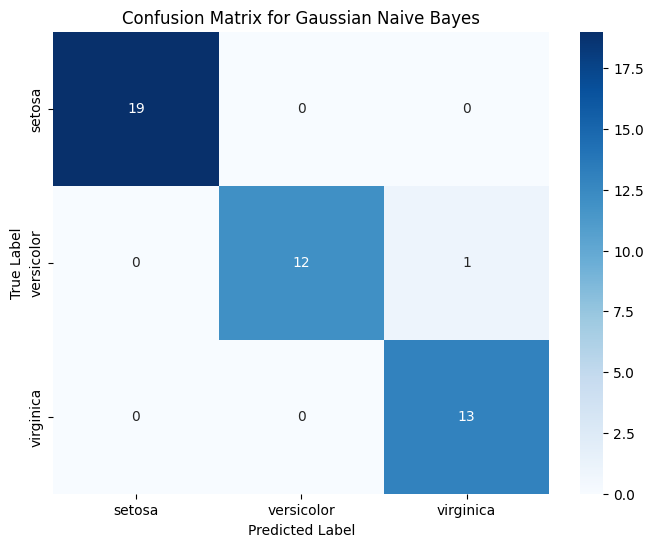


Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        19
  versicolor       1.00      0.92      0.96        13
   virginica       0.93      1.00      0.96        13

    accuracy                           0.98        45
   macro avg       0.98      0.97      0.97        45
weighted avg       0.98      0.98      0.98        45



In [ ]:
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy Score: {accuracy:.2f}")

conf_matrix = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(conf_matrix)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=iris.target_names, yticklabels=iris.target_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for Gaussian Naive Bayes')
plt.show()

class_report = classification_report(y_test, y_pred, target_names=iris.target_names)
print("\nClassification Report:")
print(class_report)